In [1]:
import pandas as pd
import numpy as np
from glob import glob
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

# use the seaborn whitegrid style
plt.style.use('seaborn-v0_8-whitegrid')

# Helper function

In [2]:
def summarize_hyperparam(env, mu_type, alg_names):
    def summ_ep(df):
        delta = df.delta.abs().mean()
        delta_obs = df.delta_obs.abs().mean()
        rew = df.sort_values("t")["resource"].values[-1]
        accept_g0 = df[df.group_id == 0].action.mean()
        accept_g1 = df[df.group_id == 1].action.mean()
        return pd.Series(
            {
                "delta": delta,
                "delta_last": df.sort_values("t")["delta"].values[-1],
                "delta_obs": delta_obs,
                "reward": rew,
                "accept_g0": accept_g0,
                "accept_g1": accept_g1,
            }
        )

    files = [
        f"experiments/{env}/{mu_type}/{alg}/eval/eval_data.csv" for alg in alg_names
    ]
    results = []
    for file in files:
        try:
            alg = file.split("/")[-3]
            df = pd.read_csv(file)
            df = df.groupby("ep").apply(summ_ep).aggregate(["mean", "std"])
            alg_simplified = alg.replace("sellf_hard", "sellf").split("_")[0]
            results.append(
                {
                    "alg": alg,
                    "alg_simplified": alg_simplified,
                    "delta": df["delta"]["mean"],
                    "delta_std": df["delta"]["std"],
                    "reward": df["reward"]["mean"],
                    "reward_std": df["reward"]["std"],
                    "delta_obs": df["delta_obs"]["mean"],
                    "delta_obs_std": df["delta_obs"]["std"],
                    "accept_g0": df["accept_g0"]["mean"],
                    "accept_g1": df["accept_g1"]["mean"],
                    "delta_last": df["delta_last"]["mean"],
                }
            )
        except:
            continue
    results = pd.DataFrame(results)

    def evaluate(df):
        deltas = df["delta_obs"].values.copy()
        rewards = df["reward"].values.copy()

        # round delta to 2 decimal places
        deltas = np.round(deltas, 2)
        deltas[deltas <= 0.05] = 0

        delta_min = deltas.min()
        rewards[deltas > delta_min] = 0

        df["score"] = rewards

        return df

    results = results.groupby("alg_simplified", group_keys = False).apply(evaluate).reset_index()
    return results

In [ ]:
def base_legend_func(alg_name):
    if "sellf" in alg_name:
        return "SELLF"
    if "pocar_full" in alg_name:
        return "POCAR (Oracle)"
    if "pocar" in alg_name:
        return "POCAR"
    if "ppo" in alg_name:
        return "PPO"
    return alg_name

def base_color_func(alg_name):
    if "sellf" in alg_name:
        return "#e78ac3"
    if "full" in alg_name:
        return "#fc8d62"
    if "ppo" in alg_name:
        return "#8da0cb"
    if "pocar" in alg_name:
        return "#a6d854"

In [4]:
def get_alg_names(alg_name):
    config = OmegaConf.load(f"configs/{alg_name}.yaml")
    alg_names = []
    for params in config.algorithm_param_list:
        params_info = " ".join([f"{k}:{v}" for k, v in params.items()])
        alg_names.append(f"{alg_name}({params_info})")
    
    if len(alg_names) == 0:
        alg_names.append(f"{alg_name}()")
    return alg_names


In [5]:
def base_plot(selected_algs, env_name, mu_type, save_path):
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))

    df_list = [
        pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/eval/eval_data.csv")
        for alg in selected_algs
    ]

    for i in range(len(df_list)):
        df_list[i]["accept_g0"] = df_list[i]["action"] * (df_list[i]["group_id"] == 0)
        df_list[i]["accept_g1"] = df_list[i]["action"] * (df_list[i]["group_id"] == 1)

        # for each ep, compute cumulative sum of accept_g0 and accept_g1
        df_list[i]["n_accept_g0"] = df_list[i].groupby("ep")["accept_g0"].cumsum()
        df_list[i]["n_accept_g1"] = df_list[i].groupby("ep")["accept_g1"].cumsum()

        df_list[i]["delta"] = df_list[i]["delta"].abs()

        df_list[i] = (
            df_list[i]
            .groupby("t")
            .agg(
                {
                    "resource": ["mean", "std"],
                    "delta": ["mean", "std"],
                    "n_accept_g0": ["mean", "std"],
                    "n_accept_g1": ["mean", "std"],
                }
            )
        )

    for alg, df in zip(selected_algs, df_list):
        axs[0].plot(
            df.index,
            df["resource"]["mean"],
            label=base_legend_func(alg),
            color=base_color_func(alg),
            linestyle="--" if "full" in alg else "-",
        )
        axs[0].fill_between(
            df.index,
            df["resource"]["mean"] - df["resource"]["std"],
            df["resource"]["mean"] + df["resource"]["std"],
            alpha=0.3,
            color=base_color_func(alg),
        )

        axs[1].plot(
            df.index,
            df["delta"]["mean"],
            label=base_legend_func(alg),
            color=base_color_func(alg),
            linestyle="--" if "full" in alg else "-",
        )
        axs[1].fill_between(
            df.index,
            df["delta"]["mean"] - df["delta"]["std"],
            df["delta"]["mean"] + df["delta"]["std"],
            alpha=0.3,
            color=base_color_func(alg),
        )

        #diff_accept = df["n_accept_g0"]["mean"]
        #axs[2].plot(
        #    df.index,
        #    diff_accept,
        #    label=base_legend_func(alg),
        #    color=base_color_func(alg),
        #    linestyle="--" if "full" in alg else "-",
        #    lw=2,
        #)

    for i in range(2):
        axs[i].set_xlabel("Timestep")

    axs[0].set_title("Cumulative Reward", fontsize = 12)
    axs[1].set_title("Disparity ($|\Delta_t|$)", fontsize = 12)
    #axs[2].set_title("Nº of acceptances for\nunderprivileged group")

    # place legend outside bellow all plots
    fig.subplots_adjust(bottom=0.3, wspace=0.33)

    axs[1].legend(
        loc="upper center",
        bbox_to_anchor=(-0.15, -0.3),
        ncol=len(selected_algs),
    )

    for i in range(2):
        axs[i].grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

In [6]:
def process_table(result_table):
    table = result_table[["alg", "delta", "delta_std", "reward", "reward_std"]].copy()
    # round 2 decimal places
    table["delta"] = table["delta"].round(2)
    table["delta_std"] = table["delta_std"].round(2)
    table["reward"] = table["reward"].round(2)
    table["reward_std"] = table["reward_std"].round(1)

    print("alg \t\t\t delta \t\t\t reward")
    def alg_order(alg_name):
        if "ppo" in alg_name:
            return 0
        if "pocar_full" in alg_name:
            return 2
        if "pocar" in alg_name:
            return 1
        if "sellf" in alg_name:
            return 3
        return 4

    table["order"] = table["alg"].apply(alg_order)
    table = table.sort_values(by=["order", "alg"])
    for i, row in table.iterrows():
        skip = "\t\t\t" if len(base_legend_func(row['alg'])) <= 5 else "\t\t"
        print(f"{base_legend_func(row['alg'])} {skip} & {row['delta']} ($\pm$ {row['delta_std']}) \t & {row['reward']} ($\pm$ {row['reward_std']})")


# FICO

## Ablation

In [148]:
env_name = "fico_equal"
mu_type = "accuracy"
train_files = glob(f"experiments/ablation/**/{env_name}/{mu_type}/**/models/*.csv")
eval_files = glob(f"experiments/ablation/**/{env_name}/{mu_type}/**/eval/*.csv")
alg_dict = dict([(f.split("/")[-3], []) for f in train_files])
alg_dict_eval = dict([(f.split("/")[-3], []) for f in eval_files])
for f in train_files:
    alg_name = f.split("/")[-3]
    alg_dict[alg_name].append(f)
for f in eval_files:
    alg_name = f.split("/")[-3]
    alg_dict_eval[alg_name].append(f)

In [149]:
### sumarize learning metrics

alg_dfs = {}

for alg_name, file_list in alg_dict.items():
    df_list = []
    for f in file_list:
        df = pd.read_csv(f)
        df["t"] = np.arange(len(df))
        df_list.append(df)
    df = pd.concat(df_list)
    df["delta_diff"] = (df["delta"] - df["delta_obs"])
    df["term_g0"] =(1 - df["accept_g0"]) * df["renyi_div_g0"]
    df["term_g1"] =(1 - df["accept_g1"]) * df["renyi_div_g1"]
    df["term"] = df["term_g0"] + df["term_g1"]

    # apply moving average with window size 10 for every numeric column
    for col in ["reward", "delta", "delta_obs", "delta_diff"]:
        df[col] = df[col].rolling(window=1).mean()

    df = df.groupby("t").agg({
        "reward": ["mean", "std"],
        "delta": ["mean", "std"],
        "delta_obs": ["mean", "std"],
        "delta_diff": ["mean", "std"],
        "term": ["mean", "std"],
        "accept_g0": ["mean", "std"],
        "accept_g1": ["mean", "std"],
        "max_weight_g0" : ["mean", "std"],
        "max_weight_g1" : ["mean", "std"],
        "aK_min_g0" : ["mean", "std"],
        "aK_min_g1" : ["mean", "std"],
    })
    alg_dfs[alg_name] = df

In [150]:
alg_dfs_eval = {}
for alg_name, file_list in alg_dict_eval.items():
    df_list = []
    for f in file_list:
        df = pd.read_csv(f)
        df["t"] = np.arange(len(df))
        df_list.append(df)
    df = pd.concat(df_list)
    df["delta"] = df["delta"].abs()
    df = df.groupby("t").agg({"delta" : "mean"})
    alg_dfs_eval[alg_name] = {
        "mean" : df["delta"].mean(),
        "std" : df["delta"].std()
    }

In [151]:
sorted_algs = sorted(alg_dfs, key = lambda x : float(x.split(":")[2].replace(")", "")))

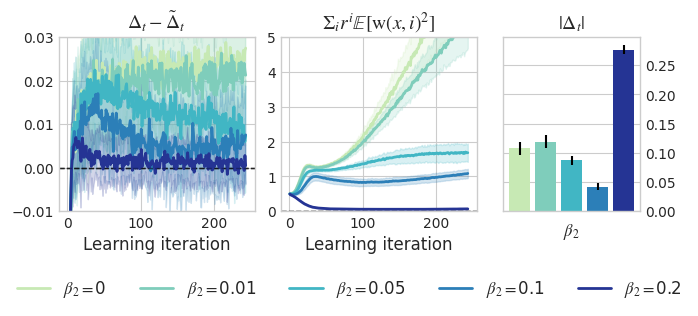

In [152]:
colors = ['#c7e9b4','#7fcdbb','#41b6c4','#2c7fb8','#253494']

def color_func(alg_name):
    idx = sorted_algs.index(alg_name)
    return colors[idx]

def legend_func(alg_name):
    return alg_name.split(" ")[-1].replace(")", "").replace("beta_2:", "$\\beta_2=$") 


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(7.5, 3), gridspec_kw={'width_ratios': [1, 1, 0.7]})


for alg_name in sorted_algs:
    df = alg_dfs[alg_name]
    axs[0].plot(
        df["delta_diff"]["mean"],
        label=(alg_name),
        color=color_func(alg_name),
        lw = 2,
    )

    axs[0].fill_between(
        df.index,
        df["delta_diff"]["mean"] - df["delta_diff"]["std"],
        df["delta_diff"]["mean"] + df["delta_diff"]["std"],
        alpha=0.2,
        color = color_func(alg_name),
    )

    axs[0].axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)


    axs[1].plot(
        df["term"]["mean"],
        label=legend_func(alg_name),
        color=color_func(alg_name), 
        lw = 2,
    )

    axs[1].fill_between(
        df.index,
        df["term"]["mean"] - df["term"]["std"],
        df["term"]["mean"] + df["term"]["std"],
        alpha=0.2,
        color = color_func(alg_name),
    )

    axs[1].axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)


    df = alg_dfs_eval[alg_name]
    axs[2].bar(
        alg_name,
        df["mean"],
        yerr=df["std"],
        color=color_func(alg_name),
    )
    axs[2].set_xticks(range(len(sorted_algs)))
    axs[2].set_xticklabels(
        ["" for s in sorted_algs],
        #[s.split(" ")[-1].replace(")", "").replace("beta_2:", "$\\beta_2=$") for s in sorted_algs],
        rotation=45,
    )
    #plt.show()

axs[0].set_ylim(-0.01, 0.03)
axs[1].set_ylim(0, 5)
axs[0].set_title(r"$\Delta_t - \tilde \Delta_t $", fontsize=14)
axs[1].set_title(r"$\Sigma_i r^i \mathbb{E}[\mathrm{w}(x, i)^2]$", fontsize=14)
axs[2].set_title(r"$|\Delta_t|$", fontsize=14)

fig.subplots_adjust(bottom=0.3, wspace=0.33)

axs[0].set_xlabel("Learning iteration", fontsize = 12)
axs[1].set_xlabel("Learning iteration", fontsize = 12)
axs[2].set_xlabel(r"$\beta_2$", fontsize = 12)
axs[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.35, -0.3),
    ncol=5,
    fontsize=12
)

for i in range(3):
    axs[i].grid(True)

# make the last only be horizontal grid
axs[-1].xaxis.grid(False)

# reduce the horizontal gap between plots


# place y ticks of last plot on the right
axs[2].yaxis.tick_right()
axs[2].yaxis.set_label_position("right")

fig.subplots_adjust(wspace=0.15)

plt.savefig("figures/ablation_beta2.pdf", bbox_inches="tight")

### Analysis of weights

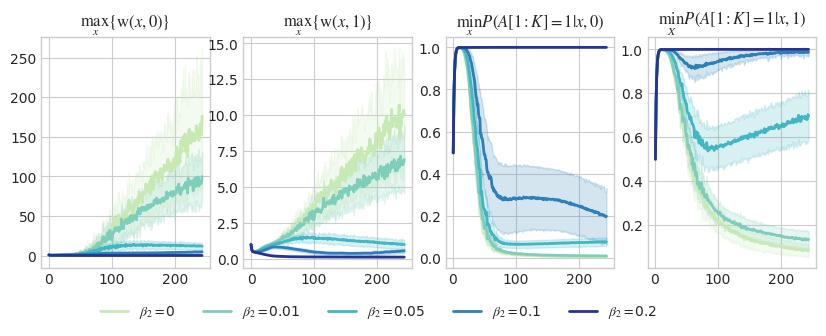

In [156]:
colors = ['#c7e9b4','#7fcdbb','#41b6c4','#2c7fb8','#253494']

def color_func(alg_name):
    idx = sorted_algs.index(alg_name)
    return colors[idx]

def legend_func(alg_name):
    return alg_name.split(" ")[-1].replace(")", "").replace("beta_2:", "$\\beta_2=$")  


fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))


for alg_name in sorted_algs:
    df = alg_dfs[alg_name]

    # first plot the weights
    axs[0].plot(
        df["max_weight_g0"]["mean"],
        label=legend_func(alg_name),
        color=color_func(alg_name),
        lw = 2,
    )

    axs[0].fill_between(
        df.index,
        df["max_weight_g0"]["mean"] - df["max_weight_g0"]["std"],
        df["max_weight_g0"]["mean"] + df["max_weight_g0"]["std"],
        alpha=0.2,
        color = color_func(alg_name),
    )

    axs[1].plot(
        df["max_weight_g1"]["mean"],
        label=legend_func(alg_name),
        color=color_func(alg_name),
        lw = 2,
    )

    axs[1].fill_between(
        df.index,
        df["max_weight_g1"]["mean"] - df["max_weight_g1"]["std"],
        df["max_weight_g1"]["mean"] + df["max_weight_g1"]["std"],
        alpha=0.2,
        color = color_func(alg_name),
    )

    # now, plot the denominators
    axs[2].plot(
        df["aK_min_g0"]["mean"],
        label=legend_func(alg_name),
        color=color_func(alg_name),
        lw = 2,
    )

    axs[2].fill_between(
        df.index,
        df["aK_min_g0"]["mean"] - df["aK_min_g0"]["std"],
        df["aK_min_g0"]["mean"] + df["aK_min_g0"]["std"],
        alpha=0.2,
        color = color_func(alg_name),
    )

    axs[3].plot(
        df["aK_min_g1"]["mean"],
        label=legend_func(alg_name),
        color=color_func(alg_name),
        lw = 2,
    )

    axs[3].fill_between(
        df.index,
        df["aK_min_g1"]["mean"] - df["aK_min_g1"]["std"],
        df["aK_min_g1"]["mean"] + df["aK_min_g1"]["std"],
        alpha=0.2,
        color = color_func(alg_name),
    )


#axs[0].set_ylim(-0.01, 0.03)
#axs[1].set_ylim(0, 5)
axs[0].set_title(r"$\max_x \{\mathrm{w}(x, 0)\}$")
axs[1].set_title(r"$\max_x \{\mathrm{w}(x, 1)\}$")
axs[2].set_title(r"$\min_x P(A[1:K] = 1 |x,0)$")
axs[3].set_title(r"$\min_X P(A[1:K] = 1 | x, 1)$")
#axs[2].set_title(r"$|\Delta_t|$")
#
#fig.subplots_adjust(bottom=0.3, wspace=0.33)
#
#axs[0].set_xlabel("Learning iteration")
#axs[1].set_xlabel("Learning iteration")
#axs[2].set_xlabel(r"$\beta_2$")
axs[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.8, -0.1),
    ncol=5,
)

for i in range(4):
   axs[i].grid(True)

#axs[2].set_xlim(0, 30)
#axs[3].set_xlim(0, 30)


plt.savefig("figures/ablation_weights.pdf", bbox_inches="tight")

## Comparative Evaluation

### Equality of opportunity

In [24]:
env_name = "fico_equal"
mu_type = "tpr"
alg_names = sum([get_alg_names(alg) for alg in ["ppo", "pocar", "pocar_full", "sellf"]], [])
results = summarize_hyperparam(env_name, mu_type, alg_names)
process_table(results.sort_values("score", ascending=False).groupby("alg_simplified").first())

alg 			 delta 			 reward
PPO 			 & 0.38 ($\pm$ 0.01) 	 & 1624.64 ($\pm$ 14.0)
POCAR 			 & 0.37 ($\pm$ 0.01) 	 & 1626.68 ($\pm$ 12.9)
POCAR (Oracle) 		 & 0.05 ($\pm$ 0.01) 	 & 1156.82 ($\pm$ 12.4)
SELLF 			 & 0.04 ($\pm$ 0.01) 	 & 1263.96 ($\pm$ 17.3)


In [25]:
selected_algs = (
    results.sort_values("score", ascending=False)
    .groupby("alg_simplified")
    .first()["alg"]
    .tolist()
)

# place sellf first
sellf_alg = [alg for alg in selected_algs if "sellf" in alg][0]
selected_algs.remove(sellf_alg)
selected_algs = [sellf_alg] + selected_algs

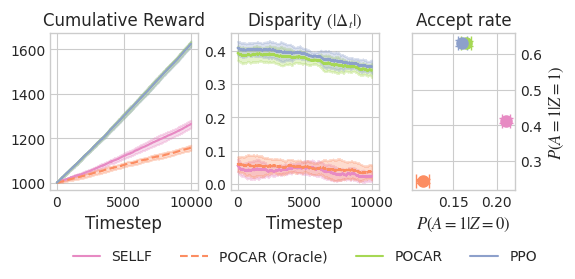

In [46]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(6, 2.7), gridspec_kw={'width_ratios': [1, 1, 0.7]})

df_list = [
    pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/eval/eval_data.csv")
    for alg in selected_algs
]

# first, let's calculate the accept rate of each alg
accept_rate_g0 = {}
accept_rate_g1 = {}

for i in range(len(df_list)):
    df_list[i]["accept_and_g0"] = df_list[i]["action"] * (df_list[i]["group_id"] == 0)
    df_list[i]["accept_and_g1"] = df_list[i]["action"] * (df_list[i]["group_id"] == 1)
    df_list[i]["g0"] = (df_list[i]["group_id"] == 0)
    df_list[i]["g1"] = (df_list[i]["group_id"] == 1)
    accept_g0 = df_list[i].groupby("ep")["accept_and_g0"].sum()
    accept_g1 = df_list[i].groupby("ep")["accept_and_g1"].sum()

    n_g0 = df_list[i].groupby("ep")["g0"].sum()
    n_g1 = df_list[i].groupby("ep")["g1"].sum()

    accept_rate_g0[selected_algs[i]] = {
        "mean": (accept_g0 / n_g0).mean(),
        "std": (accept_g0 / n_g0).std(),
    }
    accept_rate_g1[selected_algs[i]] = {
        "mean": (accept_g1 / n_g1).mean(),
        "std": (accept_g1 / n_g1).std(),
    }

    df_list[i]["delta"] = df_list[i]["delta"].abs()

    df_list[i] = (
        df_list[i]
        .groupby("t")
        .agg(
            {
                "resource": ["mean", "std"],
                "delta": ["mean", "std"],
            }
        )
    )

for alg, df in zip(selected_algs, df_list):
    

    axs[0].plot(
        df.index,
        df["resource"]["mean"],
        label=base_legend_func(alg),
        color=base_color_func(alg),
        linestyle="--" if "full" in alg else "-",
    )
    axs[0].fill_between(
        df.index,
        df["resource"]["mean"] - df["resource"]["std"],
        df["resource"]["mean"] + df["resource"]["std"],
        alpha=0.3,
        color=base_color_func(alg),
    )

    axs[1].plot(
        df.index,
        df["delta"]["mean"],
        label=base_legend_func(alg),
        color=base_color_func(alg),
        linestyle="--" if "full" in alg else "-",
    )
    axs[1].fill_between(
        df.index,
        df["delta"]["mean"] - df["delta"]["std"],
        df["delta"]["mean"] + df["delta"]["std"],
        alpha=0.3,
        color=base_color_func(alg),
    )

    # axs[2].plot(
    #     df.index,
    #     df["n_accept_g0"]["mean"],
    #     label=base_legend_func(alg),
    #     color=base_color_func(alg),
    #     linestyle="--" if "full" in alg else "-",
    #     lw=2,
    # )

    # axs[2].fill_between(
    #     df.index,
    #     df["n_accept_g0"]["mean"] - df["n_accept_g0"]["std"],
    #     df["n_accept_g0"]["mean"] + df["n_accept_g0"]["std"],
    #     alpha=0.3,
    #     color=base_color_func(alg),
    # )

    # scatter the acceptance rate
    #axs[2].scatter(
    #    [accept_rate_g0],
    #    [accept_rate_g1],
    #    label=base_legend_func(alg),
    #    color=base_color_func(alg),
    #    s=100,
    #)

    # scatter with error bars
    axs[2].errorbar(
        accept_rate_g0[alg]["mean"],
        accept_rate_g1[alg]["mean"],
        xerr=accept_rate_g0[alg]["std"],
        yerr=accept_rate_g1[alg]["std"],
        label=base_legend_func(alg),
        color=base_color_func(alg),
        fmt='o',
        markersize=8,
        capsize=5,
    )
        
for i in range(2):
    axs[i].set_xlabel("Timestep", fontsize = 12)

axs[2].set_xlabel("$P(A = 1 | Z = 0)$", fontsize = 12)
axs[2].set_ylabel("$P(A = 1 | Z = 1)$", fontsize = 12)
# place the y ticks of the last plot on the right
axs[2].yaxis.tick_right()
axs[2].yaxis.set_label_position("right")

axs[0].set_title("Cumulative Reward")
axs[1].set_title("Disparity $(|\Delta_t|)$")
axs[2].set_title("Accept rate")

# place legend outside bellow all plots
fig.subplots_adjust(bottom=0.3, wspace=0.33)

axs[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=len(selected_algs),
)

for i in range(3):
    axs[i].grid(True)

fig.subplots_adjust(wspace = 0.25)
plt.savefig("figures/fico_tpr.pdf", bbox_inches="tight", dpi=300)
plt.show()

### Accuracy

In [61]:
env_name = "fico_equal"
mu_type = "accuracy"
alg_names = sum([get_alg_names(alg) for alg in ["ppo", "pocar", "pocar_full", "sellf"]], [])
results = summarize_hyperparam(env_name, mu_type, alg_names)
process_table(results.sort_values("score", ascending=False).groupby("alg_simplified").first())

alg 			 delta 			 reward
PPO 			 & 0.04 ($\pm$ 0.01) 	 & 1624.64 ($\pm$ 14.0)
POCAR 			 & 0.06 ($\pm$ 0.0) 	 & 1611.6 ($\pm$ 15.2)
POCAR (Oracle) 		 & 0.08 ($\pm$ 0.0) 	 & 1417.88 ($\pm$ 21.7)
SELLF 			 & 0.07 ($\pm$ 0.01) 	 & 1617.54 ($\pm$ 20.5)


In [62]:
selected_algs = (
    results.sort_values("score", ascending=False)
    .groupby("alg_simplified")
    .first()["alg"]
    .tolist()
)

# place sellf first
sellf_alg = [alg for alg in selected_algs if "sellf" in alg][0]
selected_algs.remove(sellf_alg)
selected_algs = [sellf_alg] + selected_algs

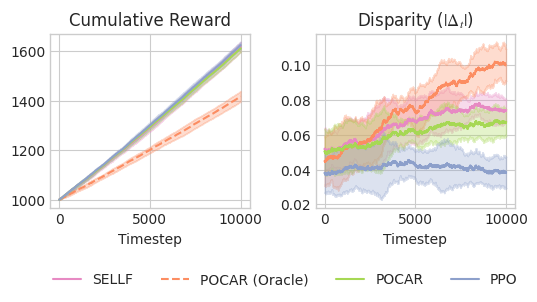

In [65]:
base_plot(selected_algs, env_name, mu_type, "figures/fico_accuracy.pdf")

### Qualification parity

In [70]:
env_name = "fico_equal"
mu_type = "qualification"
alg_names = sum([get_alg_names(alg) for alg in ["ppo", "pocar", "pocar_full", "sellf"]], [])
results = summarize_hyperparam(env_name, mu_type, alg_names)
process_table(results.sort_values("score", ascending=False).groupby("alg_simplified").first())

alg 			 delta 			 reward
PPO 			 & 0.42 ($\pm$ 0.01) 	 & 1607.42 ($\pm$ 15.7)
POCAR 			 & 0.42 ($\pm$ 0.01) 	 & 1529.86 ($\pm$ 13.3)
POCAR (Oracle) 		 & 0.42 ($\pm$ 0.01) 	 & 1556.7 ($\pm$ 13.5)
SELLF 			 & 0.42 ($\pm$ 0.01) 	 & 1611.66 ($\pm$ 29.2)


In [71]:
selected_algs = (
    results.sort_values("score", ascending=False)
    .groupby("alg_simplified")
    .first()["alg"]
    .tolist()
)

# place sellf first
sellf_alg = [alg for alg in selected_algs if "sellf" in alg][0]
selected_algs.remove(sellf_alg)
selected_algs = [sellf_alg] + selected_algs

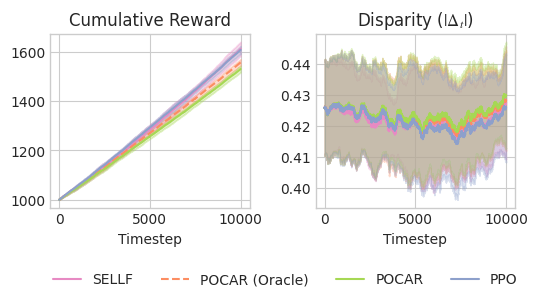

In [72]:
base_plot(selected_algs, env_name, mu_type, "figures/fico_qualification.pdf")

# ENEM

## Comparative

### Equality of opportunity

In [7]:
env_name = "enem"
mu_type = "tpr"
alg_names = sum([get_alg_names(alg) for alg in ["ppo", "pocar", "pocar_full", "sellf"]], [])
results = summarize_hyperparam(env_name, mu_type, alg_names)
process_table(results.sort_values("score", ascending=False).groupby("alg_simplified").first())

alg 			 delta 			 reward
PPO 			 & 0.27 ($\pm$ 0.02) 	 & 1211.26 ($\pm$ 13.9)
POCAR 			 & 0.27 ($\pm$ 0.02) 	 & 1210.78 ($\pm$ 14.3)
POCAR (Oracle) 		 & 0.05 ($\pm$ 0.02) 	 & 1139.36 ($\pm$ 13.6)
SELLF 			 & 0.04 ($\pm$ 0.01) 	 & 1161.36 ($\pm$ 26.3)


In [8]:
selected_algs = (
    results.sort_values("score", ascending=False)
    .groupby("alg_simplified")
    .first()["alg"]
    .tolist()
)

# place sellf first
sellf_alg = [alg for alg in selected_algs if "sellf" in alg][0]
selected_algs.remove(sellf_alg)
selected_algs = [sellf_alg] + selected_algs

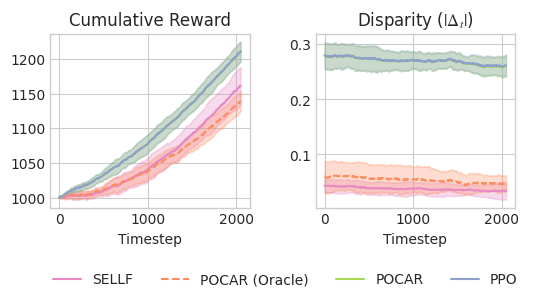

In [9]:
base_plot(selected_algs, env_name, mu_type, "figures/enem_tpr.pdf")

### Accuracy

In [10]:
env_name = "enem"
mu_type = "accuracy"
alg_names = sum([get_alg_names(alg) for alg in ["ppo", "pocar", "pocar_full", "sellf"]], [])
results = summarize_hyperparam(env_name, mu_type, alg_names)
process_table(results.sort_values("score", ascending=False).groupby("alg_simplified").first())

alg 			 delta 			 reward
PPO 			 & 0.06 ($\pm$ 0.01) 	 & 1211.26 ($\pm$ 13.9)
POCAR 			 & 0.07 ($\pm$ 0.01) 	 & 1117.5 ($\pm$ 15.4)
POCAR (Oracle) 		 & 0.05 ($\pm$ 0.01) 	 & 1179.5 ($\pm$ 15.4)
SELLF 			 & 0.05 ($\pm$ 0.01) 	 & 1193.28 ($\pm$ 18.6)


In [11]:
selected_algs = (
    results.sort_values("score", ascending=False)
    .groupby("alg_simplified")
    .first()["alg"]
    .tolist()
)

# place sellf first
sellf_alg = [alg for alg in selected_algs if "sellf" in alg][0]
selected_algs.remove(sellf_alg)
selected_algs = [sellf_alg] + selected_algs

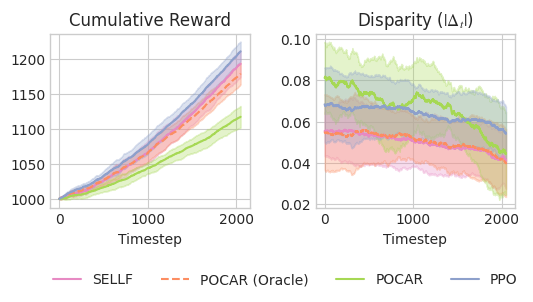

In [12]:
base_plot(selected_algs, env_name, mu_type, "figures/enem_accuracy.pdf")

### Qualification parity

In [47]:
env_name = "enem"
mu_type = "qualification"
alg_names = get_alg_names("ppo") + get_alg_names("sellf") + get_alg_names("pocar") + get_alg_names("pocar_full")
results = summarize_hyperparam(env_name, mu_type, alg_names)
process_table(results.sort_values("score", ascending=False).groupby("alg_simplified").first())

alg 			 delta 			 reward
PPO 			 & 0.15 ($\pm$ 0.01) 	 & 1219.68 ($\pm$ 23.0)
POCAR 			 & 0.14 ($\pm$ 0.01) 	 & 1203.02 ($\pm$ 25.4)
POCAR (Oracle) 		 & 0.12 ($\pm$ 0.01) 	 & 1069.16 ($\pm$ 20.5)
SELLF 			 & 0.12 ($\pm$ 0.01) 	 & 1131.58 ($\pm$ 26.7)


In [48]:
selected_algs = (
    results.sort_values("score", ascending=False)
    .groupby("alg_simplified")
    .first()["alg"]
    .tolist()
)

# place sellf first
sellf_alg = [alg for alg in selected_algs if "sellf" in alg][0]
selected_algs.remove(sellf_alg)
selected_algs = [sellf_alg] + selected_algs

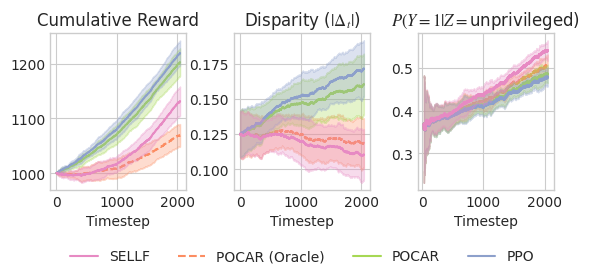

In [60]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(6.5, 2.7))

df_list = [
    pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/eval/eval_data.csv")
    for alg in selected_algs
]

for i in range(len(df_list)):
    df_list[i]["accept_g0"] = df_list[i]["action"] * (df_list[i]["group_id"] == 0)
    df_list[i]["accept_g1"] = df_list[i]["action"] * (df_list[i]["group_id"] == 1)

    # for each ep, compute cumulative sum of accept_g0 and accept_g1
    df_list[i]["n_accept_g0"] = df_list[i].groupby("ep")["accept_g0"].cumsum()
    df_list[i]["n_accept_g1"] = df_list[i].groupby("ep")["accept_g1"].cumsum()

    # for each ep, calculate a rolling window of label with window 50
    df_list[i]["label"] = (
        df_list[i]
        .groupby("ep")["label"]
        .rolling(window=500, min_periods=30)
        .mean()
        .reset_index(0, drop=True)
    )

    df_list[i]["delta"] = df_list[i]["delta"].abs()

    df_list[i] = (
        df_list[i]
        .groupby("t")
        .agg(
            {
                "resource": ["mean", "std"],
                "delta": ["mean", "std"],
                "n_accept_g0": ["mean", "std"],
                "n_accept_g1": ["mean", "std"],
                "label": ["mean", "std"],
            }
        )
    )


for alg, df in zip(selected_algs, df_list):
    axs[0].plot(
        df.index,
        df["resource"]["mean"],
        label=base_legend_func(alg),
        color=base_color_func(alg),
        linestyle="--" if "full" in alg else "-",
        zorder = 2 if "sellf" in alg else 1,
    )
    axs[0].fill_between(
        df.index,
        df["resource"]["mean"] - df["resource"]["std"],
        df["resource"]["mean"] + df["resource"]["std"],
        alpha=0.3,
        color=base_color_func(alg),
        zorder = 2 if "sellf" in alg else 1,
    )

    axs[1].plot(
        df.index,
        df["delta"]["mean"],
        label=base_legend_func(alg),
        color=base_color_func(alg),
        linestyle="--" if "full" in alg else "-",
        zorder = 2 if "sellf" in alg else 1,
    )
    axs[1].fill_between(
        df.index,
        df["delta"]["mean"] - df["delta"]["std"],
        df["delta"]["mean"] + df["delta"]["std"],
        alpha=0.3,
        color=base_color_func(alg),
        zorder = 2 if "sellf" in alg else 1,
    )

    axs[2].plot(
        df.index,
        df["label"]["mean"],
        label=base_legend_func(alg),
        color=base_color_func(alg),
        linestyle="--" if "full" in alg else "-",
        lw=2,
        zorder = 2 if "sellf" in alg else 1,
    )
    axs[2].fill_between(
        df.index,
        df["label"]["mean"] - df["label"]["std"],
        df["label"]["mean"] + df["label"]["std"],
        alpha=0.3,
        color=base_color_func(alg),
        zorder = 2 if "sellf" in alg else 1,
    )

for i in range(3):
    axs[i].set_xlabel("Timestep")

axs[0].set_title("Cumulative Reward", fontsize = 12)
axs[1].set_title("Disparity ($|\Delta_t|$)", fontsize = 12)
axs[2].set_title("$P(Y = 1 | Z = $unprivileged)", fontsize = 12)

# place legend outside bellow all plots
fig.subplots_adjust(bottom=0.3, wspace=0.33)

axs[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=len(selected_algs),
)

for i in range(3):
    axs[i].grid(True)
# make y ticks of last plot on the right

fig.subplots_adjust(wspace = 0.35)
plt.savefig("figures/enem_qualification.pdf", bbox_inches="tight")
plt.show()